# CCO02: Analyze data/240603

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import anndata
import os
import glob

In [2]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO02

In [3]:
# DATA_DIR = '/home/herbert/PyProjects/cocultured_organ/data/231221/SC149__BVO-14D-JW-121123/filtered_feature_bc_matrix.h5'
DATA_DIR = '/home/herbert/PyProjects/cocultured_organ/data/240603'
OUT_DIR = '/home/herbert/PyProjects/cocultured_organ/workspace/CCO02'

## 1 standard scanpy workflow

In [5]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO02/umap
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO02/processed
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO02/qc

In [6]:
%%capture

for d1 in glob.glob(f"{DATA_DIR}/*"):
    if not os.path.isdir(d1):
        continue
    else:
        sample_name = d1.split('/')[-1]
        
    if not os.path.isdir(f"{OUT_DIR}/qc/{sample_name}"):
        os.mkdir(f"{OUT_DIR}/qc/{sample_name}")
    
    # load h5 file
    adata = sc.read_10x_h5(f'{d1}/filtered_feature_bc_matrix.h5')
    adata.var_names_make_unique()
    
    # QC plots
    adata.var["mt"] = adata.var_names.str.startswith("MT-")
    adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
    adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")
    sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)
    
    fig, ax = plt.subplots(1, 1, figsize=(12, 5))
    sc.pl.violin(
        adata,
        ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
        jitter=0.4,
        multi_panel=True,
        show=False,
        ax=ax
    )
    plt.savefig(f"{OUT_DIR}/qc/{sample_name}/violin_plots.png")
    plt.close()
    
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    sc.pl.scatter(adata, x="total_counts", y="pct_counts_mt", show=False, ax=axs[0])
    sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts", show=False, ax=axs[1])
    plt.savefig(f"{OUT_DIR}/qc/{sample_name}/scatter_plots.png")
    plt.close()
    
    # processing 
    sc.pp.filter_cells(adata, min_genes=200)
    sc.pp.filter_genes(adata, min_cells=3)
    adata = adata[adata.obs.pct_counts_mt < 10, :].copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, n_top_genes=5000)
    # adata = adata[:, adata.var['highly_variable']]
    sc.pp.scale(adata, max_value=10)
    
    # prepare umap
    sc.tl.pca(adata, svd_solver='arpack')
    sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
    sc.tl.leiden(adata)
    sc.tl.umap(adata)
    
    # write to h5ad
    adata.write(f'{OUT_DIR}/processed/{sample_name}.h5ad')

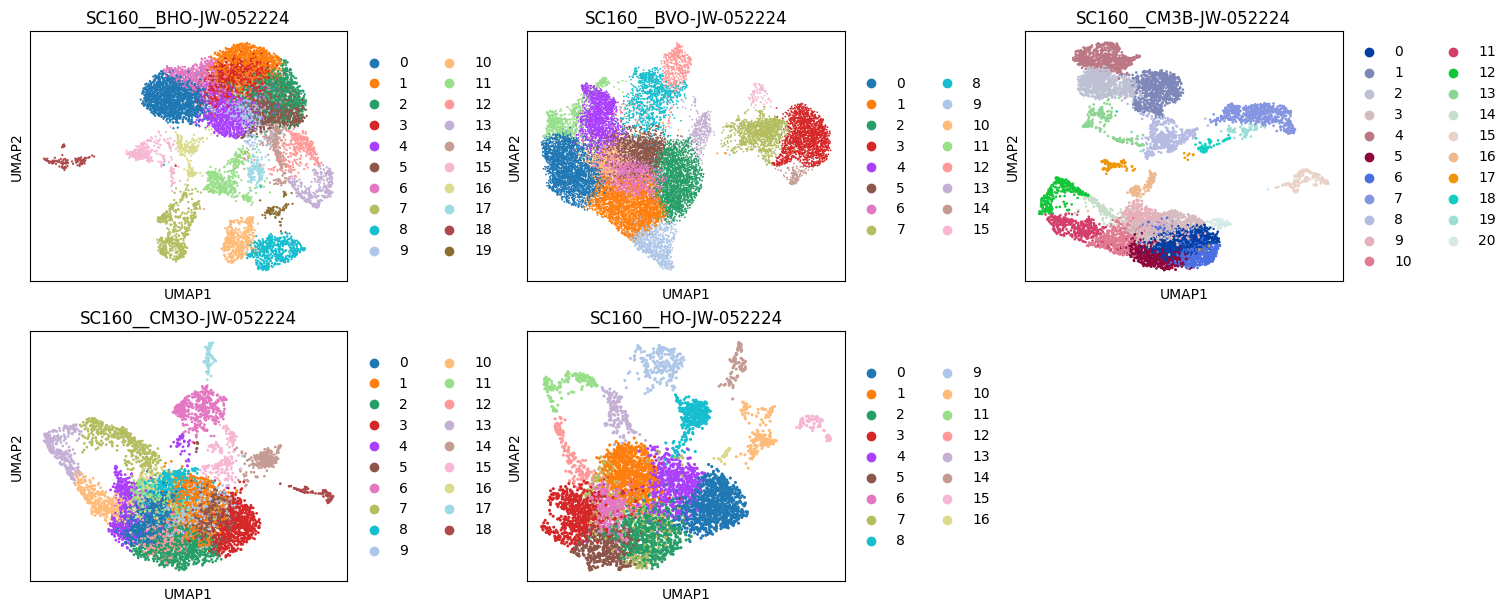

In [7]:
%%capture --no-display
fig, axs = plt.subplots(2, 3, figsize=(15,6), layout="constrained")
axs = axs.flatten()
axs[-1].remove()

for i, d1 in enumerate(glob.glob(f'{OUT_DIR}/processed/*.h5ad')):
    sample_name = d1.split('/')[-1].strip('.h5ad')
    adata = sc.read_h5ad(f'{OUT_DIR}/processed/{sample_name}.h5ad')
    sc.pl.umap(adata, color='leiden', ax=axs[i], title=sample_name, show=False)
    
plt.savefig(f'{OUT_DIR}/umap/umaps.png')
plt.show()

## 2 co-embedding

In [8]:
adata_bvo = sc.read_h5ad(f'{OUT_DIR}/processed/SC160__BVO-JW-052224.h5ad')
adata_bvo

AnnData object with n_obs × n_vars = 18379 × 23182
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'leiden'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'leiden', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [ ]:
# to guarantee the balance: subsample so that len(adata_cm3) = len(adata_ho) + len(adata_bvo)

adata_bvo = sc.read_h5ad(f'{OUT_DIR}/processed/SC160__BVO-JW-052224.h5ad')
adata_ho = sc.read_h5ad(f'{OUT_DIR}/processed/SC160__HO-JW-052224.h5ad')
adata_cm3 = sc.read_h5ad(f'{OUT_DIR}/processed/SC160__BHO-JW-052224.h5ad')

ho_bvo_ratio = 2
sc.pp.subsample(adata_bvo, n_obs=int(len(adata_cm3)*(1/(ho_bvo_ratio+1))), random_state=42)
# sc.pp.subsample(adata_ho, n_obs=int(len(adata_cm3)*(ho_bvo_ratio/(ho_bvo_ratio+1))), random_state=42)

# join adata

adata_all = adata_bvo.concatenate(adata_ho, adata_cm3, batch_key='batch')

batch_mapping = {
    '0': 'BVO',
    '1': 'HO',
    '2': 'BHO'
}
adata_all.obs['batch'] = adata_all.obs['batch'].map(batch_mapping)

# proporgate knn graph

n_neighbors = 1000
sc.tl.pca(adata_all, svd_solver='arpack', n_comps=100, random_state=42)
sc.pp.neighbors(adata_all, n_pcs=100, n_neighbors=n_neighbors, random_state=42)
sc.tl.umap(adata_all)

# plot

fig, ax = plt.subplots(1, 1)
sc.pl.umap(adata_all, color='batch', wspace=0.6, title='Co-Embedding', ax=ax, show=False)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/umap/coembedding.BHO.n_neighbor{n_neighbors}.png')
plt.show()

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/anndata/_core/anndata.py:1763: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


## 3 cell type labelling

In [34]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO02/biomarkers

In [31]:
# adata.var['gene_ids']

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: N

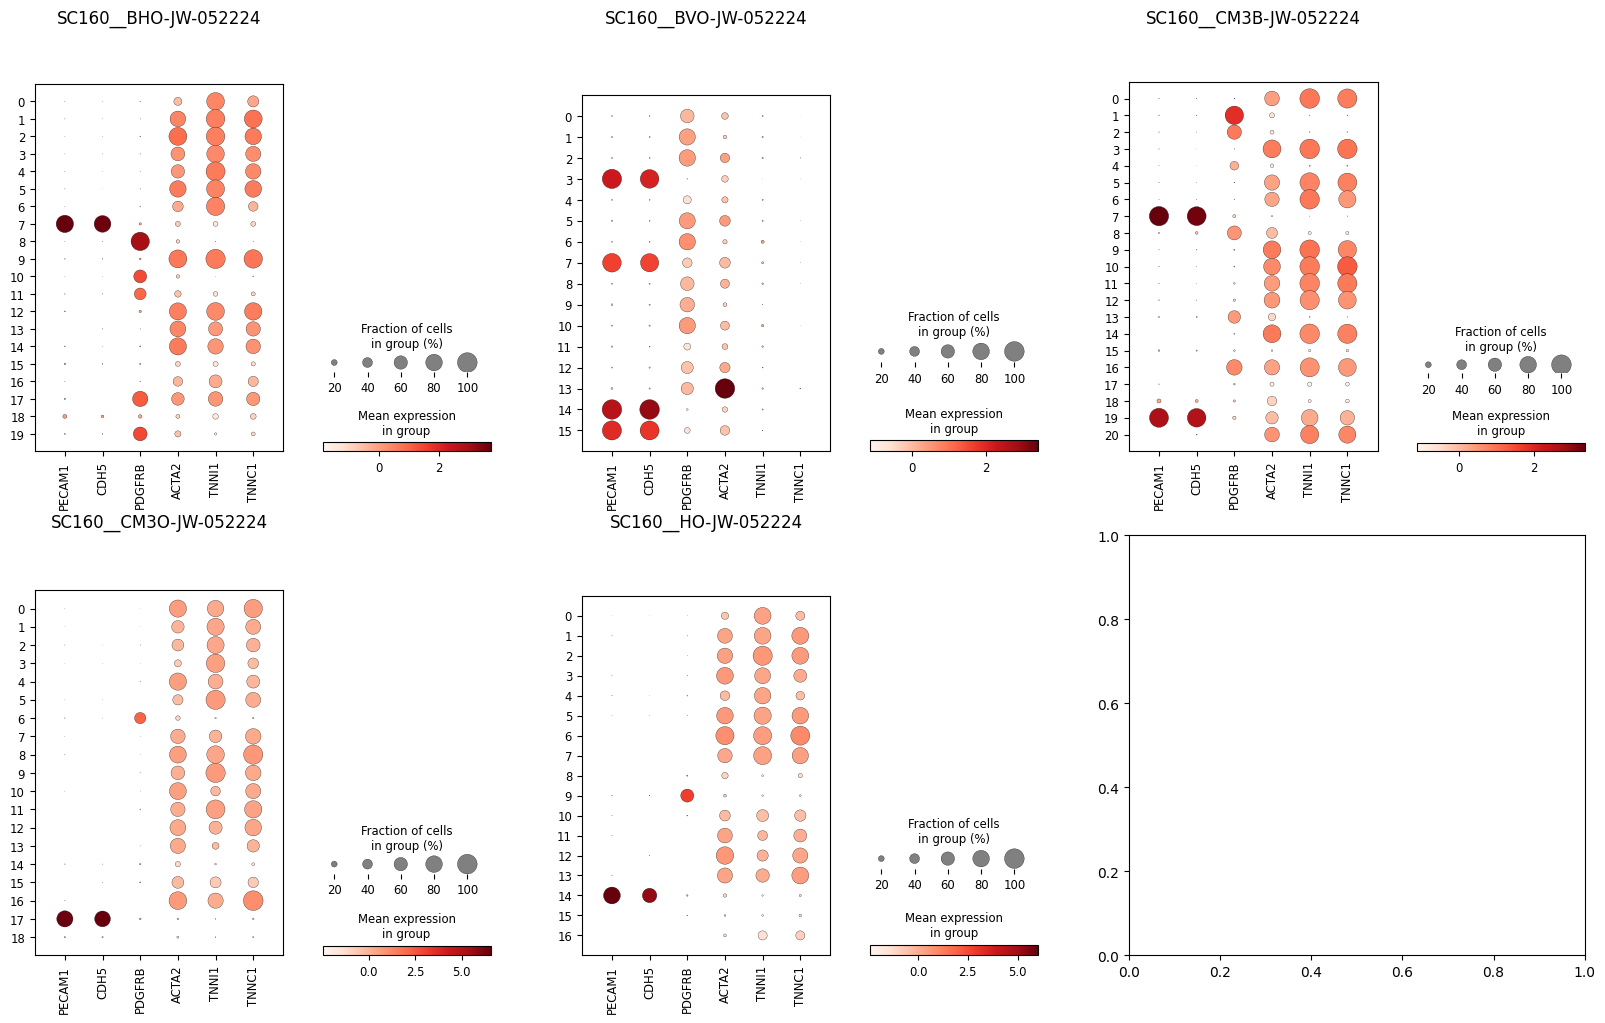

In [11]:
fig, axs = plt.subplots(2, 3, figsize=(20,12), layout="constrained")
axs = axs.flatten()
# axs[-1].remove()

markers = ['PECAM1', 'CDH5', 'PDGFRB', 'ACTA2', 'TNNI1', 'TNNC1']

# for i, d1 in enumerate(glob.glob(f'{OUT_DIR}/processed/*.h5ad')):
#     try:
#         sample_name = d1.split('/')[-1].strip('.h5ad')
#         adata = sc.read_h5ad(f'{OUT_DIR}/processed/{sample_name}.h5ad')
#         sc.pl.dotplot(adata, var_names=markers, groupby='leiden', ax=axs[i], title=sample_name, show=False)
#     except:
#         continue

for i, d1 in enumerate(glob.glob(f'{OUT_DIR}/processed/*.h5ad')):
    # try:
    sample_name = d1.split('/')[-1].strip('.h5ad')
    adata = sc.read_h5ad(f'{OUT_DIR}/processed/{sample_name}.h5ad')
    sc.pl.dotplot(adata, var_names=markers, groupby='leiden', ax=axs[i], title=sample_name, show=False)
    # except:
    #     continue
    
plt.savefig(f'{OUT_DIR}/biomarkers/dotplots.png')
plt.show()